
### Notebook to compare the old and new photometry

We output a number of comparison plots, in addition to a manually curated final photometry file.



In [ ]:

""" reading in useful packages """

import numpy as np
import pandas as pd

from datetime import date
from astropy.time import Time

import math

import matplotlib.pyplot as plt
import matplotlib.ticker as tck
import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm

# setting figure style
plt.rcParams.update({
    "text.usetex" : False,
    "font.family" : "Arial", 
    "mathtext.fontset" : "stix",
    "font.size" : 12
})

fontsize = plt.rcParams["font.size"]


In [ ]:

""" defining some things ... """

transient_name = "SN2025sei"




### Defining some useful functions



In [2]:

def fnu2ABmag(flux):
    # simple function to convert flux --> AB mag
    mag = -2.5 * np.log10(flux) + 23.90 # flux in micro-Jy
    return mag


def ABmag2fnu(mag):
    # simple function to convert AB mag --> flux
    flux = 10**((mag - 23.90) / (-2.5))
    return flux


def efnu2eABmag(flux, eflux):
    # simple function to convert flux error --> AB mag error
    emag = (2.5 / np.log(10)) * (eflux / flux)
    return emag

def eABmag2efnu(mag, emag):
    # simple function to convert AB mag error --> flux error
    eflux = (
        (np.log(10) / 2.5)
        * 10**((mag - 23.90) / (-2.5))
        * emag
    )
    return eflux


In [ ]:

""" reading in Pan-STARRS photometry file """

today = date.today() # NOTE. Only works if run on the same day as the previous script

PS_phot = pd.read_csv(f"{transient_name}_Pan-STARRS_photometry_{today}.csv", sep=",")

PS_phot


,mjd,filter,filter_centre(AA),filter_width(AA),TotalExptime(s),Mag(AB),eMag(AB),Flux(uJy),eFlux(uJy),Mag_rounded(AB),eMag_rounded(AB),DetectionSignificance,Flux_UL(3-sigma),Flux_UL(5-sigma),Mag_UL(3-sigma),Mag_UL(5-sigma)
0,60892.409343,i,7503.03,1206.62,180.0,18.114290,0.016579,206.197756,3.148646,18.11,0.02,65.487756,NaN,NaN,NaN,NaN
1,60900.442922,i,7503.03,1206.62,360.0,18.125492,0.028004,204.081236,5.263798,18.13,0.03,38.770717,NaN,NaN,NaN,NaN
2,60901.329090,g,4810.16,1053.08,120.0,18.154415,0.040537,198.716537,7.301230,18.15,0.04,27.216858,NaN,NaN,NaN,NaN
3,60901.330700,r,6155.47,1252.41,120.0,18.199813,0.039698,190.578972,6.869330,18.20,0.04,27.743459,NaN,NaN,NaN,NaN
4,60901.332280,i,7503.03,1206.62,120.0,18.218288,0.042408,187.363395,7.398990,18.22,0.04,25.322834,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,60978.214070,r,6155.47,1252.41,120.0,31.401500,10436.063828,0.000999,9.611970,31.40,10436.06,0.000104,28.83591,48.05985,20.250166,19.695544
104,60978.215630,i,7503.03,1206.62,120.0,20.995910,0.523012,14.508952,7.286240,21.00,0.52,1.991281,21.85872,36.43120,20.550938,19.996316
105,60978.217200,z,8668.36,997.72,120.0,20.550895,0.418072,21.859598,8.596640,20.55,0.42,2.542807,25.78992,42.98320,20.371375,19.816753
106,60978.218840,y,9613.60,638.98,120.0,19.811798,0.933819,43.179818,38.985130,19.81,0.93,1.107597,116.95539,194.92565,18.729949,18.175328


In [ ]:

""" converting MJDs --> standard date-time UTC format """

MJDs = Time(PS_phot["mjd"], format='mjd')

PS_phot["DateTime(UTC)"] = MJDs.iso

PS_phot



### [OPTIONAL] The below cells can be used to manually curate the final photometry file; i.e., we can manually remove bad measurements



In [ ]:

# """ clipping bad data points """

# # 60919.34566 | r --- impacted by a satellite trail

# indexes = PS_phot[(PS_phot["mjd"] == 60919.34566) & (PS_phot["filter"] == "r")].index.values[0]

# print(PS_phot.iloc[indexes])

# PS_phot.drop(indexes, inplace=True)
# PS_phot.reset_index(drop=True, inplace=True)

# PS_phot


mjd                      60919.34566
filter                             r
filter_centre(AA)            6155.47
filter_width(AA)             1252.41
TotalExptime(s)                120.0
Mag(AB)                    18.257882
eMag(AB)                    0.048683
Flux(uJy)                 180.653901
eFlux(uJy)                   8.06156
Mag_rounded(AB)                18.26
eMag_rounded(AB)                0.05
DetectionSignificance      22.409298
Flux_UL(3-sigma)                 NaN
Flux_UL(5-sigma)                 NaN
Mag_UL(3-sigma)                  NaN
Mag_UL(5-sigma)                  NaN
Name: 37, dtype: object


,mjd,filter,filter_centre(AA),filter_width(AA),TotalExptime(s),Mag(AB),eMag(AB),Flux(uJy),eFlux(uJy),Mag_rounded(AB),eMag_rounded(AB),DetectionSignificance,Flux_UL(3-sigma),Flux_UL(5-sigma),Mag_UL(3-sigma),Mag_UL(5-sigma)
0,60892.409343,i,7503.03,1206.62,180.0,18.114290,0.016579,206.197756,3.148646,18.11,0.02,65.487756,NaN,NaN,NaN,NaN
1,60900.442922,i,7503.03,1206.62,360.0,18.125492,0.028004,204.081236,5.263798,18.13,0.03,38.770717,NaN,NaN,NaN,NaN
2,60901.329090,g,4810.16,1053.08,120.0,18.154415,0.040537,198.716537,7.301230,18.15,0.04,27.216858,NaN,NaN,NaN,NaN
3,60901.330700,r,6155.47,1252.41,120.0,18.199813,0.039698,190.578972,6.869330,18.20,0.04,27.743459,NaN,NaN,NaN,NaN
4,60901.332280,i,7503.03,1206.62,120.0,18.218288,0.042408,187.363395,7.398990,18.22,0.04,25.322834,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,60978.214070,r,6155.47,1252.41,120.0,31.401500,10436.063828,0.000999,9.611970,31.40,10436.06,0.000104,28.83591,48.05985,20.250166,19.695544
103,60978.215630,i,7503.03,1206.62,120.0,20.995910,0.523012,14.508952,7.286240,21.00,0.52,1.991281,21.85872,36.43120,20.550938,19.996316
104,60978.217200,z,8668.36,997.72,120.0,20.550895,0.418072,21.859598,8.596640,20.55,0.42,2.542807,25.78992,42.98320,20.371375,19.816753
105,60978.218840,y,9613.60,638.98,120.0,19.811798,0.933819,43.179818,38.985130,19.81,0.93,1.107597,116.95539,194.92565,18.729949,18.175328


In [ ]:

""" outputting a final column containing a mix of detections and upper limits """

mag_values_threesigma = []
emag_values_threesigma = []
upper_limit_boolean = []

for aa in range(len(PS_phot)):
    tmp_df = PS_phot.iloc[aa]

    if math.isnan(tmp_df["Mag_UL(3-sigma)"]) is False:
        mag_values_threesigma.append(tmp_df["Mag_UL(3-sigma)"])
        emag_values_threesigma.append(np.nan)
        upper_limit_boolean.append("True")
    else:
        mag_values_threesigma.append(tmp_df["Mag(AB)"])
        emag_values_threesigma.append(tmp_df["eMag(AB)"])
        upper_limit_boolean.append("False")



PS_phot["Final_Mag(AB)"] = mag_values_threesigma
PS_phot["Final_eMag(AB)"] = emag_values_threesigma
PS_phot["UL?"] = upper_limit_boolean

PS_phot["Final_rounded_Mag(AB)"] = PS_phot["Final_Mag(AB)"].round(2)
PS_phot["Final_rounded_eMag(AB)"] = PS_phot["Final_eMag(AB)"].round(2)

PS_phot


,mjd,filter,filter_centre(AA),filter_width(AA),TotalExptime(s),Mag(AB),eMag(AB),Flux(uJy),eFlux(uJy),Mag_rounded(AB),...,Flux_UL(3-sigma),Flux_UL(5-sigma),Mag_UL(3-sigma),Mag_UL(5-sigma),DateTime(UTC),Final_Mag(AB),Final_eMag(AB),UL?,Final_rounded_Mag(AB),Final_rounded_eMag(AB)
0,60892.409343,i,7503.03,1206.62,180.0,18.114290,0.016579,206.197756,3.148646,18.11,...,NaN,NaN,NaN,NaN,2025-08-05 09:49:27.192,18.114290,0.016579,False,18.11,0.02
1,60900.442922,i,7503.03,1206.62,360.0,18.125492,0.028004,204.081236,5.263798,18.13,...,NaN,NaN,NaN,NaN,2025-08-13 10:37:48.504,18.125492,0.028004,False,18.13,0.03
2,60901.329090,g,4810.16,1053.08,120.0,18.154415,0.040537,198.716537,7.301230,18.15,...,NaN,NaN,NaN,NaN,2025-08-14 07:53:53.376,18.154415,0.040537,False,18.15,0.04
3,60901.330700,r,6155.47,1252.41,120.0,18.199813,0.039698,190.578972,6.869330,18.20,...,NaN,NaN,NaN,NaN,2025-08-14 07:56:12.480,18.199813,0.039698,False,18.20,0.04
4,60901.332280,i,7503.03,1206.62,120.0,18.218288,0.042408,187.363395,7.398990,18.22,...,NaN,NaN,NaN,NaN,2025-08-14 07:58:28.992,18.218288,0.042408,False,18.22,0.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,60978.214070,r,6155.47,1252.41,120.0,31.401500,10436.063828,0.000999,9.611970,31.40,...,28.83591,48.05985,20.250166,19.695544,2025-10-30 05:08:15.648,20.250166,NaN,True,20.25,NaN
103,60978.215630,i,7503.03,1206.62,120.0,20.995910,0.523012,14.508952,7.286240,21.00,...,21.85872,36.43120,20.550938,19.996316,2025-10-30 05:10:30.432,20.550938,NaN,True,20.55,NaN
104,60978.217200,z,8668.36,997.72,120.0,20.550895,0.418072,21.859598,8.596640,20.55,...,25.78992,42.98320,20.371375,19.816753,2025-10-30 05:12:46.080,20.371375,NaN,True,20.37,NaN
105,60978.218840,y,9613.60,638.98,120.0,19.811798,0.933819,43.179818,38.985130,19.81,...,116.95539,194.92565,18.729949,18.175328,2025-10-30 05:15:07.776,18.729949,NaN,True,18.73,NaN


In [ ]:

""" saving final curated photometry file """

PS_phot = pd.to_csv(f"{transient_name}_Pan-STARRS_photometry_ZP-corrected_{today}.csv", sep=",")

PS_phot



### All of the below is for plotting purposes



In [ ]:

""" splitting the dataframe by filter - useful for plotting purposes """

PS_phot_g = PS_phot[PS_phot["filter"] == "g"].reset_index(drop=True)
PS_phot_r = PS_phot[PS_phot["filter"] == "r"].reset_index(drop=True)
PS_phot_i = PS_phot[PS_phot["filter"] == "i"].reset_index(drop=True)
PS_phot_z = PS_phot[PS_phot["filter"] == "z"].reset_index(drop=True)
PS_phot_y = PS_phot[PS_phot["filter"] == "y"].reset_index(drop=True)

PS_phot_i


,mjd,filter,filter_centre(AA),filter_width(AA),TotalExptime(s),Mag(AB),eMag(AB),Flux(uJy),eFlux(uJy),Mag_rounded(AB),...,Flux_UL(3-sigma),Flux_UL(5-sigma),Mag_UL(3-sigma),Mag_UL(5-sigma),DateTime(UTC),Final_Mag(AB),Final_eMag(AB),UL?,Final_rounded_Mag(AB),Final_rounded_eMag(AB)
0,60892.409343,i,7503.03,1206.62,180.0,18.114290,0.016579,206.197756,3.148646,18.11,...,NaN,NaN,NaN,NaN,2025-08-05 09:49:27.192,18.114290,0.016579,False,18.11,0.02
1,60900.442922,i,7503.03,1206.62,360.0,18.125492,0.028004,204.081236,5.263798,18.13,...,NaN,NaN,NaN,NaN,2025-08-13 10:37:48.504,18.125492,0.028004,False,18.13,0.03
2,60901.332280,i,7503.03,1206.62,120.0,18.218288,0.042408,187.363395,7.398990,18.22,...,NaN,NaN,NaN,NaN,2025-08-14 07:58:28.992,18.218288,0.042408,False,18.22,0.04
3,60905.318410,i,7503.03,1206.62,120.0,18.342018,0.049826,167.183321,7.673010,18.34,...,NaN,NaN,NaN,NaN,2025-08-18 07:38:30.624,18.342018,0.049826,False,18.34,0.05
4,60907.467620,i,7503.03,1206.62,120.0,18.174714,0.044077,195.035844,8.063530,18.17,...,NaN,NaN,NaN,NaN,2025-08-20 11:13:22.368,18.174714,0.044077,False,18.17,0.04
5,60910.299880,i,7503.03,1206.62,120.0,18.319779,0.033370,170.642894,5.404000,18.32,...,NaN,NaN,NaN,NaN,2025-08-23 07:11:49.632,18.319779,0.033370,False,18.32,0.03
6,60912.298510,i,7503.03,1206.62,120.0,18.361282,0.048227,164.243114,7.368440,18.36,...,NaN,NaN,NaN,NaN,2025-08-25 07:09:51.264,18.361282,0.048227,False,18.36,0.05
7,60914.315290,i,7503.03,1206.62,120.0,18.389631,0.046314,160.010216,6.885560,18.39,...,NaN,NaN,NaN,NaN,2025-08-27 07:34:01.056,18.389631,0.046314,False,18.39,0.05
8,60917.294800,i,7503.03,1206.62,120.0,18.487178,0.028093,146.261128,3.864470,18.49,...,NaN,NaN,NaN,NaN,2025-08-30 07:04:30.720,18.487178,0.028093,False,18.49,0.03
9,60919.347230,i,7503.03,1206.62,120.0,18.747876,0.068888,115.040172,7.377520,18.75,...,NaN,NaN,NaN,NaN,2025-09-01 08:20:00.672,18.747876,0.068888,False,18.75,0.07


In [ ]:

""" reading in the default Pan-STARRS forced photometry table -- for comparison """

forced_phot_df = pd.read_csv("Bundles/forced_phot_2026-05-05.txt", sep="\s+")

forced_phot_df = forced_phot_df.rename(columns={"#mjd" : "mjd"})

# rounding the MJD column entries to match the 3 d.p. in the offsets df loaded above
forced_phot_df["mjd"] = forced_phot_df["mjd"].round(3)

forced_phot_df["cal_psf_mag"] = forced_phot_df["cal_psf_mag"].astype(float)

# forced_phot_df.dtypes
# forced_phot_df


<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/var/folders/xt/j74p0pm17zx1hxv9vz8_rxkr0000gq/T/ipykernel_45668/80267693.py:4: SyntaxWarning: invalid escape sequence '\s'
  forced_phot_df = pd.read_csv("Bundles/forced_phot_2026-05-05.txt", sep="\s+")


mjd                  float64
cal_psf_mag          float64
psf_inst_mag_sig     float64
psf_inst_flux        float64
psf_inst_flux_sig    float64
filter                object
exptime              float64
zero_pt              float64
fpa_id                 int64
ujy                  float64
dujy                 float64
pscamera              object
dtype: object

In [ ]:

""" splitting the dataframe by filter - useful for plotting purposes """

forced_phot_g = forced_phot_df[forced_phot_df["filter"] == "g"].reset_index(drop=True)
forced_phot_r = forced_phot_df[forced_phot_df["filter"] == "r"].reset_index(drop=True)
forced_phot_i = forced_phot_df[forced_phot_df["filter"] == "i"].reset_index(drop=True)
forced_phot_z = forced_phot_df[forced_phot_df["filter"] == "z"].reset_index(drop=True)
forced_phot_y = forced_phot_df[forced_phot_df["filter"] == "y"].reset_index(drop=True)

forced_phot_i


,mjd,cal_psf_mag,psf_inst_mag_sig,psf_inst_flux,psf_inst_flux_sig,filter,exptime,zero_pt,fpa_id,ujy,dujy,pscamera
0,57591.397,NaN,41.814100,-13.9351,582.685,i,45.0,24.5445,1420723,-0.17104,7.15190,GPC1
1,57591.410,NaN,1.169930,-525.2250,614.476,i,45.0,24.5447,1420744,-6.44544,7.54071,GPC1
2,57591.422,21.6179,0.795674,663.4820,527.916,i,45.0,24.5394,1420778,8.18195,6.51017,GPC1
3,57591.434,21.4077,0.654044,804.7090,526.315,i,45.0,24.5388,1420796,9.92902,6.49401,GPC1
4,57883.459,NaN,0.895779,-1560.2000,1397.590,i,45.0,24.5094,1533227,-19.77916,17.71770,GPC1
...,...,...,...,...,...,...,...,...,...,...,...,...
97,60960.248,20.3275,0.200014,5799.6900,1160.020,i,120.0,24.5381,2774517,26.85243,5.37086,GPC1
98,60967.283,NaN,2.517730,-780.5470,1965.210,i,120.0,24.4319,2777772,-3.98527,10.03385,GPC1
99,60973.224,NaN,0.892682,-1983.8700,1770.970,i,120.0,24.5208,2779560,-9.33280,8.33125,GPC1
100,60978.216,20.9507,0.481713,3111.8400,1499.010,i,120.0,24.4853,2780561,15.12572,7.28624,GPC1



### Making the main figure 



<>:159: SyntaxWarning: invalid escape sequence '\s'
<>:197: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
<>:62: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
<>:86: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
<>:111: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
<>:138: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
<>:159: SyntaxWarning: invalid escape sequence '\s'
<>:197: SyntaxWarning: invalid escape sequence '\m'
/var/folders/xt/j74p0pm17zx1hxv9vz8_rxkr0000gq/T/ipykernel_45668/2745809226.py:159: SyntaxWarning: invalid escape sequence '\s'
  ax_mag.plot(60000, 25, color="black", marker="v", linestyle='',  label="Upper limit ($3 \sigma$)")
/var/folders/xt/j74p0pm17zx1hxv9vz8_rxkr0000gq/T/ipykernel_45668/2745809226.py:197: SyntaxWarning: invalid escape sequence '\m'
  ax_fnu.set_ylabel("Observed flux density ($\mu$Jy)")
/var/folders/xt/j74p0pm17zx1hxv9vz8_rxkr0000gq/T

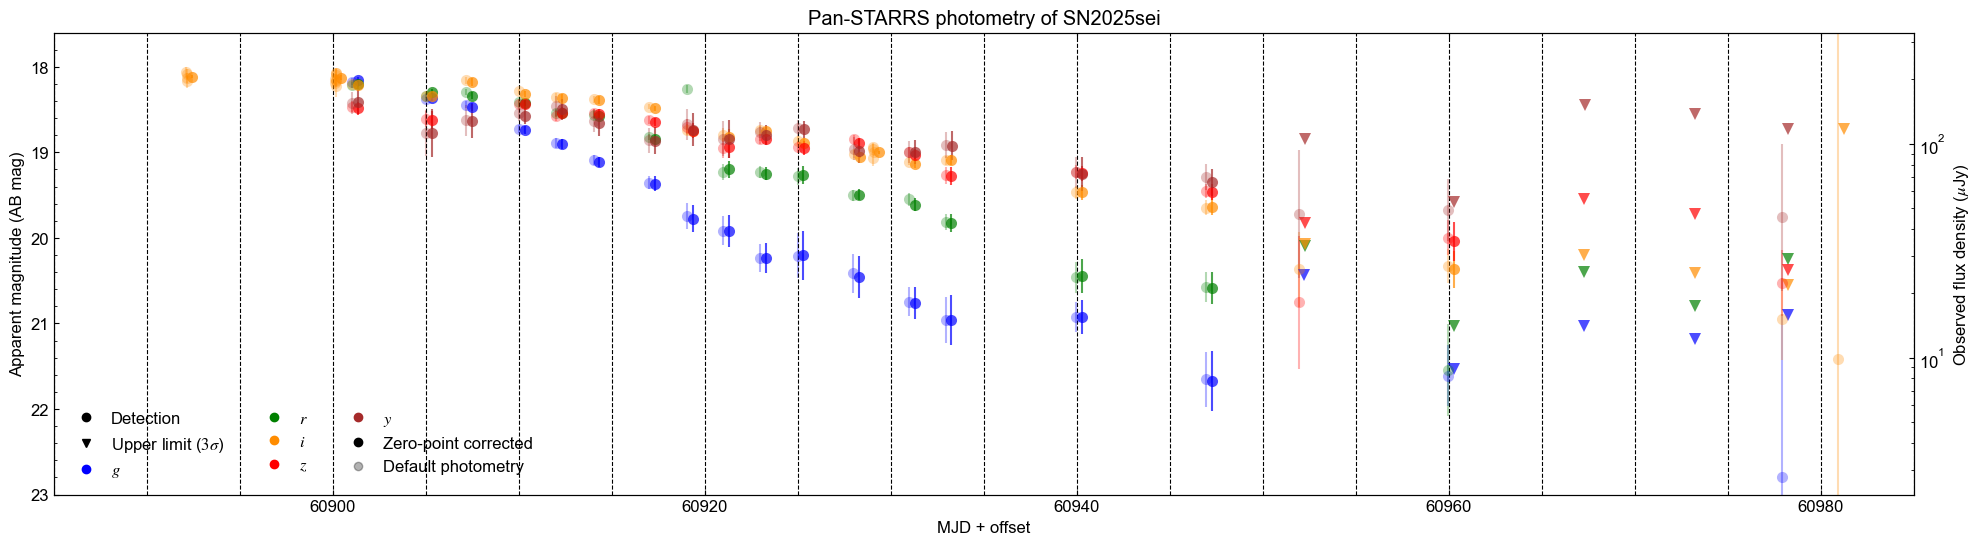

In [ ]:

# Creating figure
fig = plt.figure(figsize=(24, 6))

# defining the rest wavelength axis
ax_mag = plt.subplot()
ax_mag.tick_params(axis='both', direction='in', top=True, right=False, left=True, bottom=True, which='both')
ax_mag.xaxis.set_minor_locator(tck.AutoMinorLocator())
ax_mag.yaxis.set_minor_locator(tck.AutoMinorLocator())

ax_mag.set_axisbelow(False)

# defining the observed wavelength axis
ax_fnu = ax_mag.twinx()
ax_fnu.tick_params(axis='both', direction='in', top=False, right=True, left=False, bottom=False, which='both')
ax_fnu.xaxis.set_minor_locator(tck.AutoMinorLocator())
ax_fnu.yaxis.set_minor_locator(tck.AutoMinorLocator())

# plotting the data with errors
colorlist = ["blue", "green", "darkorange", "red", "brown"]
colorlist_counter = 0

markersize = 8
mjd_offset = 0.3


for aa in range(len(PS_phot_g)):
    tmp_df = PS_phot_g.iloc[aa]

    mjd = tmp_df["mjd"]
    mag = tmp_df["Final_Mag(AB)"]
    emag = tmp_df["Final_eMag(AB)"]
    is_UL = tmp_df["UL?"]

    if is_UL is "True":
        marker = "v"
    else:
        marker = "o"
    
    ax_mag.plot(mjd, mag, label=r"", color=colorlist[colorlist_counter], marker=marker, markersize=markersize, linestyle='', alpha=0.7, zorder=9, markeredgewidth=0.0)
    ax_mag.errorbar(mjd, mag, yerr=emag, ecolor=colorlist[colorlist_counter], linestyle='', alpha=0.7)

ax_mag.plot(forced_phot_g["mjd"]-mjd_offset, forced_phot_g["cal_psf_mag"], label=r"", color=colorlist[colorlist_counter], marker="o", markersize=markersize, linestyle='', alpha=0.3, zorder=9, markeredgewidth=0.0)
ax_mag.errorbar(forced_phot_g["mjd"]-mjd_offset, forced_phot_g["cal_psf_mag"], yerr=forced_phot_g["psf_inst_mag_sig"], ecolor=colorlist[colorlist_counter], linestyle='', alpha=0.3)

colorlist_counter += 1

#######################################################################################################################
#######################################################################################################################


for aa in range(len(PS_phot_r)):
    tmp_df = PS_phot_r.iloc[aa]

    mjd = tmp_df["mjd"]
    mag = tmp_df["Final_Mag(AB)"]
    emag = tmp_df["Final_eMag(AB)"]
    is_UL = tmp_df["UL?"]

    if is_UL is "True":
        marker = "v"
    else:
        marker = "o"
    
    ax_mag.plot(mjd, mag, label=r"", color=colorlist[colorlist_counter], marker=marker, markersize=markersize, linestyle='', alpha=0.7, zorder=9, markeredgewidth=0.0)
    ax_mag.errorbar(mjd, mag, yerr=emag, ecolor=colorlist[colorlist_counter], linestyle='', alpha=0.7)

ax_mag.plot(forced_phot_r["mjd"]-mjd_offset, forced_phot_r["cal_psf_mag"], label=r"", color=colorlist[colorlist_counter], marker="o", markersize=markersize, linestyle='', alpha=0.3, zorder=9, markeredgewidth=0.0)
ax_mag.errorbar(forced_phot_r["mjd"]-mjd_offset, forced_phot_r["cal_psf_mag"], yerr=forced_phot_r["psf_inst_mag_sig"], ecolor=colorlist[colorlist_counter], linestyle='', alpha=0.3)

colorlist_counter += 1

#######################################################################################################################
#######################################################################################################################


for aa in range(len(PS_phot_i)):
    tmp_df = PS_phot_i.iloc[aa]

    mjd = tmp_df["mjd"]
    mag = tmp_df["Final_Mag(AB)"]
    emag = tmp_df["Final_eMag(AB)"]
    is_UL = tmp_df["UL?"]

    if is_UL is "True":
        marker = "v"
    else:
        marker = "o"
    
    ax_mag.plot(mjd, mag, label=r"", color=colorlist[colorlist_counter], marker=marker, markersize=markersize, linestyle='', alpha=0.7, zorder=9, markeredgewidth=0.0)
    ax_mag.errorbar(mjd, mag, yerr=emag, ecolor=colorlist[colorlist_counter], linestyle='', alpha=0.7)

ax_mag.plot(forced_phot_i["mjd"]-mjd_offset, forced_phot_i["cal_psf_mag"], label=r"", color=colorlist[colorlist_counter], marker="o", markersize=markersize, linestyle='', alpha=0.3, zorder=9, markeredgewidth=0.0)
ax_mag.errorbar(forced_phot_i["mjd"]-mjd_offset, forced_phot_i["cal_psf_mag"], yerr=forced_phot_i["psf_inst_mag_sig"], ecolor=colorlist[colorlist_counter], linestyle='', alpha=0.3)

colorlist_counter += 1

#######################################################################################################################
#######################################################################################################################


for aa in range(len(PS_phot_z)):
    tmp_df = PS_phot_z.iloc[aa]

    mjd = tmp_df["mjd"]
    mag = tmp_df["Final_Mag(AB)"]
    emag = tmp_df["Final_eMag(AB)"]
    is_UL = tmp_df["UL?"]

    if is_UL is "True":
        marker = "v"
    else:
        marker = "o"
    
    ax_mag.plot(mjd, mag, label=r"", color=colorlist[colorlist_counter], marker=marker, markersize=markersize, linestyle='', alpha=0.7, zorder=9, markeredgewidth=0.0)
    ax_mag.errorbar(mjd, mag, yerr=emag, ecolor=colorlist[colorlist_counter], linestyle='', alpha=0.7)


ax_mag.plot(forced_phot_z["mjd"]-mjd_offset, forced_phot_z["cal_psf_mag"], label=r"", color=colorlist[colorlist_counter], marker="o", markersize=markersize, linestyle='', alpha=0.3, zorder=9, markeredgewidth=0.0)
ax_mag.errorbar(forced_phot_z["mjd"]-mjd_offset, forced_phot_z["cal_psf_mag"], yerr=forced_phot_z["psf_inst_mag_sig"], ecolor=colorlist[colorlist_counter], linestyle='', alpha=0.3)

colorlist_counter += 1

#######################################################################################################################
#######################################################################################################################


for aa in range(len(PS_phot_y)):
    tmp_df = PS_phot_y.iloc[aa]

    mjd = tmp_df["mjd"]
    mag = tmp_df["Final_Mag(AB)"]
    emag = tmp_df["Final_eMag(AB)"]
    is_UL = tmp_df["UL?"]

    if is_UL is "True":
        marker = "v"
    else:
        marker = "o"
    
    ax_mag.plot(mjd, mag, label=r"", color=colorlist[colorlist_counter], marker=marker, markersize=markersize, linestyle='', alpha=0.7, zorder=9, markeredgewidth=0.0)
    ax_mag.errorbar(mjd, mag, yerr=emag, ecolor=colorlist[colorlist_counter], linestyle='', alpha=0.7)


ax_mag.plot(forced_phot_y["mjd"]-mjd_offset, forced_phot_y["cal_psf_mag"], label=r"", color=colorlist[colorlist_counter], marker="o", markersize=markersize, linestyle='', alpha=0.3, zorder=9, markeredgewidth=0.0)
ax_mag.errorbar(forced_phot_y["mjd"]-mjd_offset, forced_phot_y["cal_psf_mag"], yerr=forced_phot_y["psf_inst_mag_sig"], ecolor=colorlist[colorlist_counter], linestyle='', alpha=0.3)

#######################################################################################################################
#######################################################################################################################


ax_mag.plot(60000, 25, color="black", marker="o", linestyle='', label="Detection")
ax_mag.plot(60000, 25, color="black", marker="v", linestyle='',  label="Upper limit ($3 \sigma$)")

ax_mag.plot(60000, 25, color=colorlist[0],  marker="o", linestyle='', label="$g$")
ax_mag.plot(60000, 25, color=colorlist[1],  marker="o", linestyle='', label="$r$")
ax_mag.plot(60000, 25, color=colorlist[2],  marker="o", linestyle='', label="$i$")
ax_mag.plot(60000, 25, color=colorlist[3],  marker="o", linestyle='', label="$z$")
ax_mag.plot(60000, 25, color=colorlist[4],  marker="o", linestyle='', label="$y$")

ax_mag.plot(60000, 25, color="black", marker="o", linestyle='', alpha=1, label="Zero-point corrected")
ax_mag.plot(60000, 25, color="black", marker="o", linestyle='', alpha=0.3, label="Default photometry")

ax_mag.set_xlim([60885, 60985])
ax_mag.set_ylim([23, 17.6])

ax_mag.grid(which='both', axis='x', linestyle="--", color="black", zorder=-999)

# First, we fix the axis range for the rest wavelength values
# This stops any last-minute re-scaling effects when other stuff is plotted
y_1, y_2 = ax_mag.get_ylim()
ax_fnu.set_ylim(y_1, y_2)

y_1 = ABmag2fnu(y_1)
y_2 = ABmag2fnu(y_2)
ax_fnu.set_ylim(y_1, y_2)

ax_fnu.set_yscale("log")

ax_mag.legend(frameon=False, edgecolor="white", loc="best", ncol=3, fontsize=fontsize, handletextpad=0.5)

ax_mag.set_xlabel("MJD + offset")
ax_mag.set_ylabel("Apparent magnitude (AB mag)")
ax_fnu.set_ylabel("Observed flux density ($\mu$Jy)")

ax_mag.set_title(f"Pan-STARRS photometry of {transient_name}")

plt.savefig(f"{transient_name}_Pan-STARRS_photometry_comparison-pre+post-ZP-corrected.pdf", dpi=900, bbox_inches="tight")
plt.show()




### Same plots as above, but split into individual filters $-$ easier to scrutinise differences induced from zero-point corrections 



<>:83: SyntaxWarning: invalid escape sequence '\s'
<>:122: SyntaxWarning: invalid escape sequence '\m'
<>:60: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
<>:83: SyntaxWarning: invalid escape sequence '\s'
<>:122: SyntaxWarning: invalid escape sequence '\m'
/var/folders/xt/j74p0pm17zx1hxv9vz8_rxkr0000gq/T/ipykernel_45668/1920575130.py:83: SyntaxWarning: invalid escape sequence '\s'
  ax_mag.plot(60000, 25, color="black", marker="v", linestyle='',  label="Upper limit ($3 \sigma$)")
/var/folders/xt/j74p0pm17zx1hxv9vz8_rxkr0000gq/T/ipykernel_45668/1920575130.py:122: SyntaxWarning: invalid escape sequence '\m'
  ax_fnu.set_ylabel("Observed flux density ($\mu$Jy)")
/var/folders/xt/j74p0pm17zx1hxv9vz8_rxkr0000gq/T/ipykernel_45668/1920575130.py:60: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  if is_UL is "True":


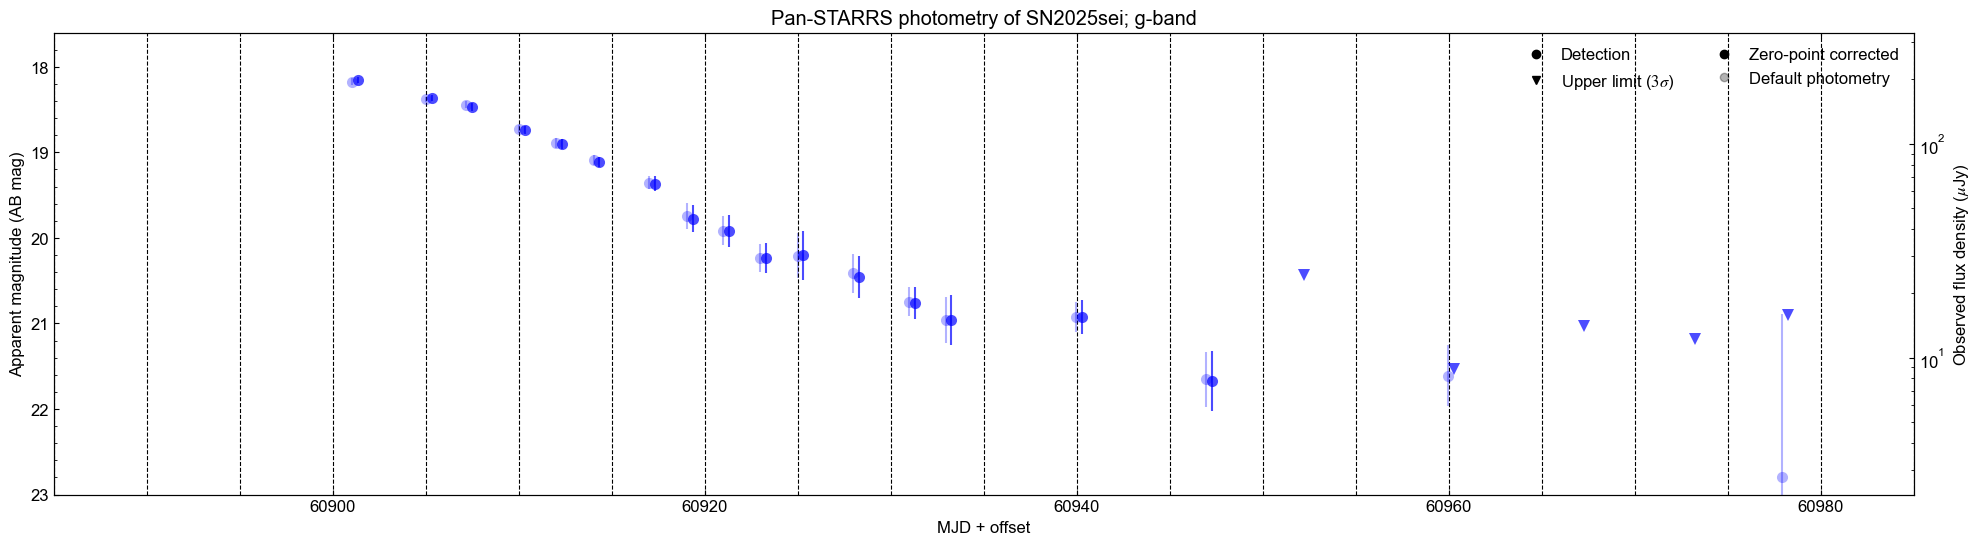

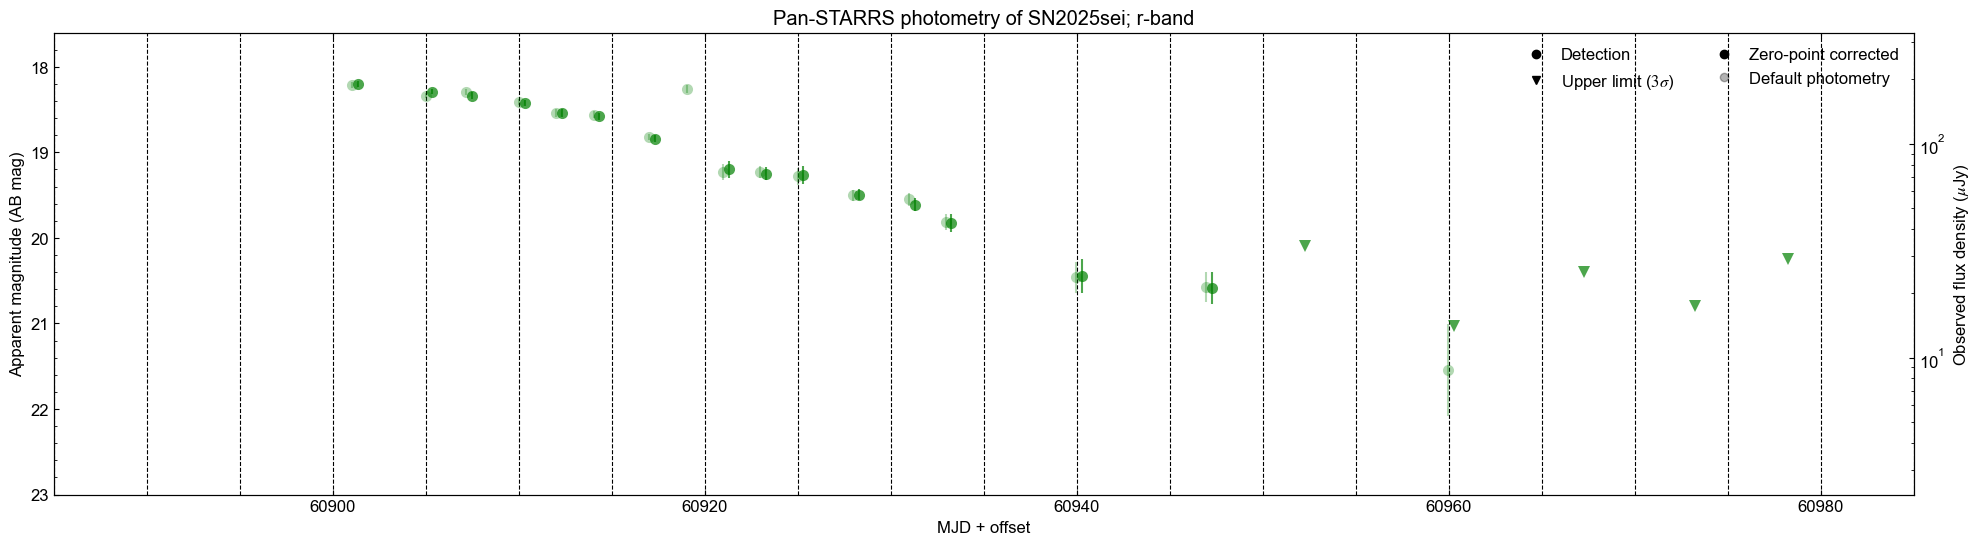

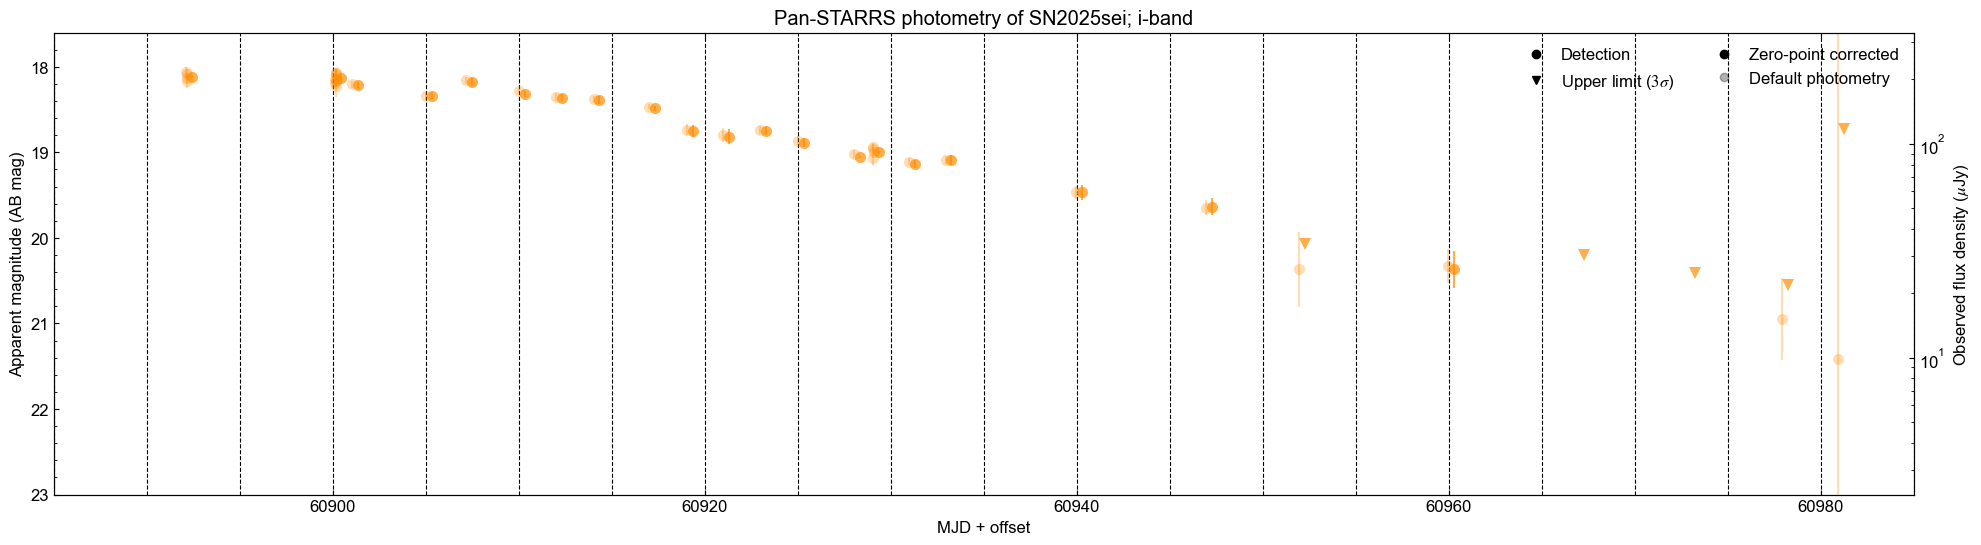

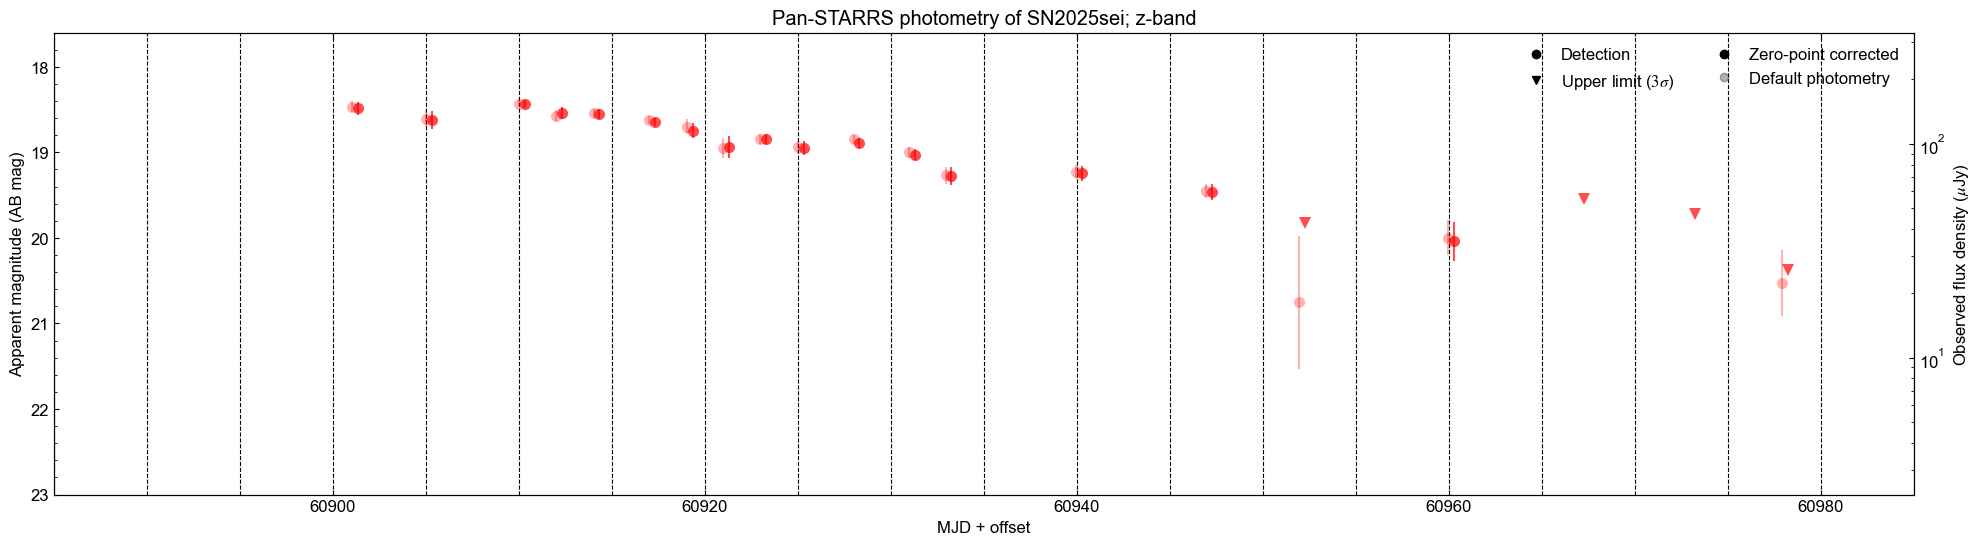

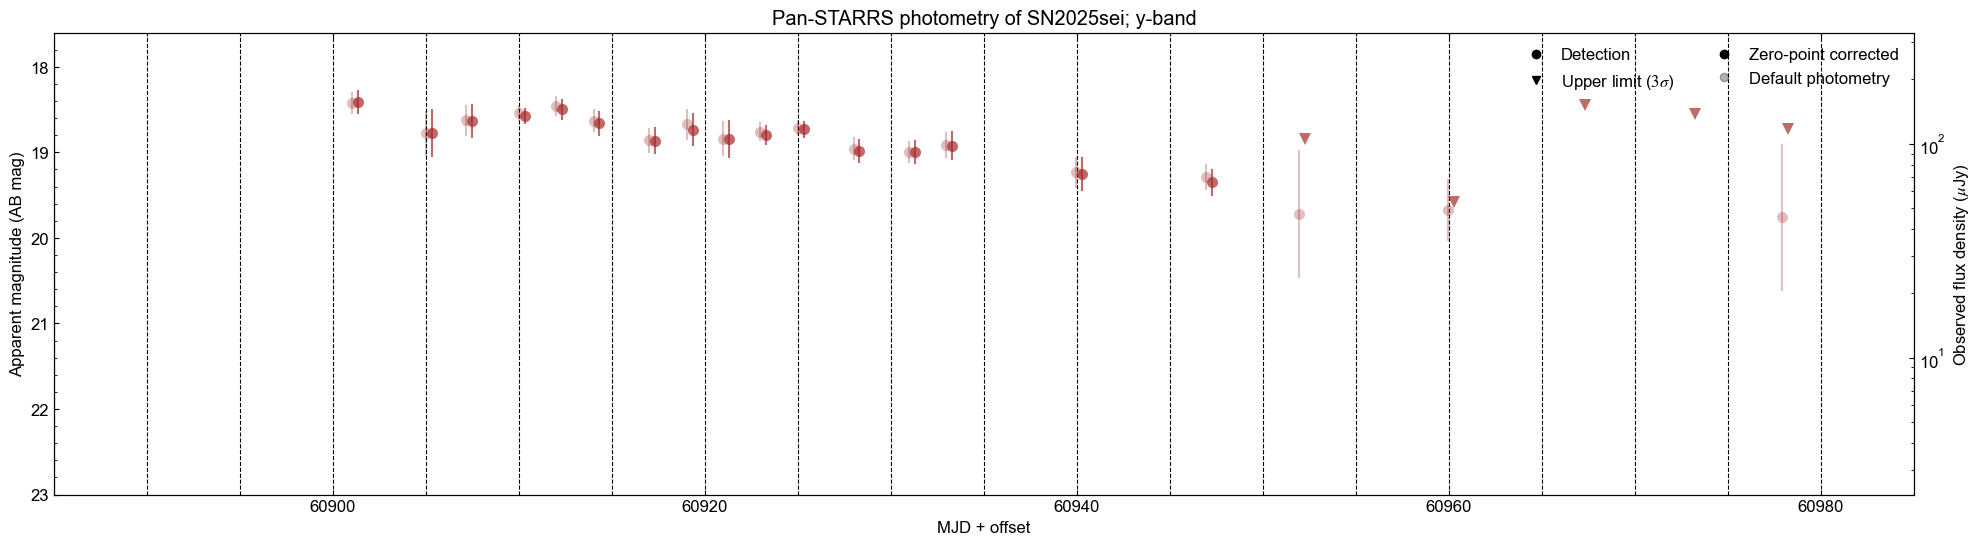

In [ ]:

# plotting the data with errors
# colorlist = cm.gist_rainbow(np.linspace(0.1, 0.9, 4))
colorlist = ["blue", "green", "darkorange", "red", "brown"]
colorlist_counter = 0

markersize = 8
mjd_offset = 0.3

forced_phots_list = [
    forced_phot_g,
    forced_phot_r,
    forced_phot_i,
    forced_phot_z,
    forced_phot_y,
]

PS_phots_list = [
    PS_phot_g,
    PS_phot_r,
    PS_phot_i,
    PS_phot_z,
    PS_phot_y,
]

for forced_phots, PS_phots in zip(forced_phots_list, PS_phots_list):

    # Creating figure
    fig = plt.figure(figsize=(24, 6))

    # defining the rest wavelength axis
    ax_mag = plt.subplot()
    ax_mag.tick_params(axis='both', direction='in', top=True, right=False, left=True, bottom=True, which='both')
    ax_mag.xaxis.set_minor_locator(tck.AutoMinorLocator())
    ax_mag.yaxis.set_minor_locator(tck.AutoMinorLocator())

    ax_mag.set_axisbelow(False)

    # defining the observed wavelength axis
    ax_fnu = ax_mag.twinx()
    ax_fnu.tick_params(axis='both', direction='in', top=False, right=True, left=False, bottom=False, which='both')
    ax_fnu.xaxis.set_minor_locator(tck.AutoMinorLocator())
    ax_fnu.yaxis.set_minor_locator(tck.AutoMinorLocator())


    for aa in range(len(PS_phots)):
        tmp_df = PS_phots.iloc[aa]

        mjd = tmp_df["mjd"]
        mag = tmp_df["Final_Mag(AB)"]
        emag = tmp_df["Final_eMag(AB)"]
        is_UL = tmp_df["UL?"]

        filter = tmp_df["filter"]

        if is_UL is "True":
            marker = "v"
        else:
            marker = "o"
        
        ax_mag.plot(mjd, mag, label=r"", color=colorlist[colorlist_counter], marker=marker, markersize=markersize, linestyle='', alpha=0.7, zorder=9, markeredgewidth=0.0)
        ax_mag.errorbar(mjd, mag, yerr=emag, ecolor=colorlist[colorlist_counter], linestyle='', alpha=0.7)

    ax_mag.plot(forced_phots["mjd"]-mjd_offset, forced_phots["cal_psf_mag"], label=r"", color=colorlist[colorlist_counter], marker="o", markersize=markersize, linestyle='', alpha=0.3, zorder=9, markeredgewidth=0.0)
    ax_mag.errorbar(forced_phots["mjd"]-mjd_offset, forced_phots["cal_psf_mag"], yerr=forced_phots["psf_inst_mag_sig"], ecolor=colorlist[colorlist_counter], linestyle='', alpha=0.3)

    colorlist_counter += 1

    #######################################################################################################################
    #######################################################################################################################


    ax_mag.plot(60000, 25, color="black", marker="o", linestyle='', label="Detection")
    ax_mag.plot(60000, 25, color="black", marker="v", linestyle='',  label="Upper limit ($3 \sigma$)")

    ax_mag.plot(60000, 25, color="black", marker="o", linestyle='', alpha=1, label="Zero-point corrected")
    ax_mag.plot(60000, 25, color="black", marker="o", linestyle='', alpha=0.3, label="Default photometry")

    ax_mag.set_xlim([60885, 60985])
    ax_mag.set_ylim([23, 17.6])

    ax_mag.grid(which='both', axis='x', linestyle="--", color="black", zorder=-999)

    # First, we fix the axis range for the rest wavelength values
    # This stops any last-minute re-scaling effects when other stuff is plotted
    y_1, y_2 = ax_mag.get_ylim()
    ax_fnu.set_ylim(y_1, y_2)

    y_1 = ABmag2fnu(y_1)
    y_2 = ABmag2fnu(y_2)
    ax_fnu.set_ylim(y_1, y_2)

    ax_fnu.set_yscale("log")

    ax_mag.legend(frameon=False, edgecolor="white", loc="best", ncol=2, fontsize=fontsize, handletextpad=0.5)

    ax_mag.set_xlabel("MJD + offset")
    ax_mag.set_ylabel("Apparent magnitude (AB mag)")
    ax_fnu.set_ylabel("Observed flux density ($\mu$Jy)")

    ax_mag.set_title(f"Pan-STARRS photometry of {transient_name}; {filter}-band")

    plt.savefig(f"{transient_name}_Pan-STARRS_photometry_comparison-pre+post-ZP-corrected_{filter}.pdf", dpi=900, bbox_inches="tight")
    plt.show()
